# **Banco de Dados - Não Relacional**

**Instituição:** Pontifícia Universidade Católica de Campinas

**Curso:** Ciência de Dados e Inteligência Artificial

**Professor:** Felipe Cavalaro  

---

## Integrantes

| Nome | RA |
| :--- | :--- |
| Alice Pasolini | 25012938 |
| Enzo Guerra | 25007153 |
| Guilherme Cintra | 25004996 |
| Julia Leandro | 25009148 |
| Lavínia Oliveira | 25894981 |

### Instalação das Dependências

In [1]:
#%pip install -r ../requirements.txt -q
# (Dependências devem estar pré-instaladas)

In [2]:
# DataFrames e funções auxiliares
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import csv

# Grafos
import networkx as nx

Conexão com MongoDB

In [3]:
import pymongo
from pymongo import MongoClient
import os
from pathlib import Path
from dotenv import load_dotenv

# Estratégia: sempre usar o caminho relativo ../
# Isso funciona tanto no Jupyter quanto quando importado como módulo

# Assumindo que o notebook está em Notebooks/
# Procuramos o .env em ../
env_path = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in dir() else '.', '..', '.env'))

# Debug
print(f"[DEBUG] CWD: {os.getcwd()}")
print(f"[DEBUG] Procurando .env em: {env_path}")
print(f"[DEBUG] Arquivo existe? {os.path.exists(env_path)}")

load_dotenv(env_path)

# Verificar se carregou
MONGODB_URI = os.getenv("MONGODB_URI")
print(f"[DEBUG] MONGODB_URI carregado? {bool(MONGODB_URI)}")

[DEBUG] CWD: c:\Users\jusou\OneDrive\Documentos\GitHub\pi_educacao_qualidade\Notebooks
[DEBUG] Procurando .env em: c:\Users\jusou\OneDrive\Documentos\GitHub\pi_educacao_qualidade\.env
[DEBUG] Arquivo existe? True
[DEBUG] MONGODB_URI carregado? True


### Puxando os datasets

In [4]:
REGIAO_CAMPINAS = ['CAMPINAS','HORTOLANDIA','SUMARE','INDAIATUBA','PAULINIA','AMERICANA','VALINHOS','SANTA BARBARA D\'OESTE']

In [5]:
# Resolver caminho relativo ao arquivo do notebook
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
CAMINHO_BASE = os.path.join(notebook_dir, "..", "Datasets Tratados")
CAMINHO_BASE = os.path.abspath(CAMINHO_BASE)

In [6]:
def puxa_dataset(arquivo):
  url = os.path.join(CAMINHO_BASE, arquivo)
  return pd.read_csv(url, sep=',')

In [7]:
sarespArq = "sarespDFTratado.csv"
sarespDF = puxa_dataset(sarespArq)

fluxoArq = "fluxoDFTratado.csv"
fluxoDF = puxa_dataset(fluxoArq)

ausArq = "ausDFTratado.csv"
ausDF = puxa_dataset(ausArq)

censoArq = "censoDFTratado.csv"
censoDF = puxa_dataset(censoArq)

In [8]:
def inserir(arquivo, colecao):
  if db is None:
    print(f"Erro: MongoDB não está conectado. Não é possível inserir em '{colecao}'.")
    return
  collection = db[colecao]
  collection.delete_many({})
  with open(os.path.join(CAMINHO_BASE, arquivo), 'r', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    collection.insert_many(reader)

In [9]:
def visualizar(colecao):
  if db is None:
    print(f"Erro: MongoDB não está conectado. Não é possível visualizar '{colecao}'.")
    return
  
  lista_dfs = []
  for i in REGIAO_CAMPINAS:
      results = db[colecao].find({ "MUNICÍPIOS" : i})
      df = pd.DataFrame(list(results))

      if not df.empty:
          df = df.drop(columns=["_id"])
          lista_dfs.append(df)

  if lista_dfs:
      df = pd.concat(lista_dfs, ignore_index=True)
      print(df.to_string())
  else:
      print(f"Nenhum dado encontrado para a coleção '{colecao}'")

In [10]:
# DataFrames e funções auxiliares
import pandas as pd
import numpy as np
import zipfile

# Formatar encoding dos arquivos
import unicodedata

# Dashboard interativo
import streamlit

# Mongo

Conexão MongoDB

In [11]:
# Carregando a URL de conexão MongoDB a partir do arquivo .env (por segurança)
MONGODB_URI = os.getenv("MONGODB_URI")
print(f"[DEBUG] MONGODB_URI definido? {bool(MONGODB_URI)}")
print(f"[DEBUG] URI começa com 'mongodb'? {str(MONGODB_URI or '').startswith('mongodb')}")

try:
    if not MONGODB_URI:
        raise ValueError("MONGODB_URI não foi definido no .env")
    
    client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=10000)
    print(f"[DEBUG] Testando conexão com MongoDB...")
    info = client.server_info()
    print(f"✓ Conectado ao MongoDB com sucesso!")
    print(f"  Versão: {info.get('version', 'desconhecida')}")
    db = client["datasets"]
except Exception as e:
    print(f"✗ Aviso: Não foi possível conectar ao MongoDB: {e}")
    client = None
    db = None

[DEBUG] MONGODB_URI definido? True
[DEBUG] URI começa com 'mongodb'? True
[DEBUG] Testando conexão com MongoDB...
✓ Conectado ao MongoDB com sucesso!
  Versão: 8.0.24


In [12]:
arquivos = {
    sarespArq : "saresp",
    ausArq : "ausencia",
    fluxoArq : "fluxo",
    censoArq : "censo"
}

In [13]:
for chave, valor in arquivos.items():
  inserir(chave, valor)

Verificação da função `inserir`

In [14]:
print("Quantidade de documentos por dataset:\n")
if db is not None:
    for nome_colecao in ["saresp", "ausencia", "fluxo", "censo"]:
        qtd = db[nome_colecao].count_documents({})
        print(f"{nome_colecao}: {qtd} documentos")
else:
    print("MongoDB não está disponível. Não é possível contar documentos.")

Quantidade de documentos por dataset:

saresp: 134 documentos
ausencia: 24 documentos
fluxo: 24 documentos
censo: 78 documentos


Visualização do documento `json` como Dataframe

In [15]:
for itens in arquivos.values():
  visualizar(itens)

                MUNICÍPIOS   ANO  SERIE_ANO        COMPETÊNCIA MÉDIA_PROFICIÊNCIA
0                 CAMPINAS  2022  2º Ano EF  LÍNGUA PORTUGUESA             178.67
1                 CAMPINAS  2022  2º Ano EF         MATEMÁTICA             186.57
2                 CAMPINAS  2022  5º Ano EF  LÍNGUA PORTUGUESA             195.97
3                 CAMPINAS  2022  5º Ano EF         MATEMÁTICA             210.67
4                 CAMPINAS  2022  9º Ano EF  LÍNGUA PORTUGUESA             237.18
5                 CAMPINAS  2022  9º Ano EF         MATEMÁTICA             242.05
6                 CAMPINAS  2023  2º Ano EF  LÍNGUA PORTUGUESA             171.73
7                 CAMPINAS  2023  2º Ano EF         MATEMÁTICA             163.45
8                 CAMPINAS  2023  5º Ano EF  LÍNGUA PORTUGUESA             194.07
9                 CAMPINAS  2023  5º Ano EF         MATEMÁTICA             205.82
10                CAMPINAS  2023  9º Ano EF  LÍNGUA PORTUGUESA             227.28
11              

In [16]:
def visualizar_com_colunas(colecao, colunas=None):
  if db is None:
    print(f"Erro: MongoDB não está conectado.")
    return None
  
  lista_dfs = []
  for i in REGIAO_CAMPINAS:
      results = db[colecao].find({ "MUNICÍPIOS" : i})
      df = pd.DataFrame(list(results))

      if not df.empty:
          df = df.drop(columns=["_id"])
          lista_dfs.append(df)

  if lista_dfs:
      df = pd.concat(lista_dfs, ignore_index=True)
      
      # Se colunas específicas foram pedidas, retorna apenas essas
      if colunas:
          return df[colunas]
      return df
  else:
      print(f"Nenhum dado encontrado para '{colecao}'")
      return None

# Exemplos de uso:
df_ausencia = visualizar_com_colunas("ausencia")
print(df_ausencia.columns)  # Ver todas as colunas

# Acessar colunas específicas


Index(['MUNICÍPIOS', 'ANO', 'TOTAL FALTAS JUST', 'TOTAL FALTAS INJUST',
       'TOTAL DIAS AUSENTES'],
      dtype='object')


# Grafos

In [17]:
visualizar_com_colunas("ausencia", ["MUNICÍPIOS", "ANO", "TOTAL DIAS AUSENTES"])

,MUNICÍPIOS,ANO,TOTAL DIAS AUSENTES
0,CAMPINAS,2022,12805
1,CAMPINAS,2023,10152
2,CAMPINAS,2024,6973
3,HORTOLANDIA,2022,1670
4,HORTOLANDIA,2023,1914
5,HORTOLANDIA,2024,1087
6,SUMARE,2022,2962
7,SUMARE,2023,2479
8,SUMARE,2024,1376
9,INDAIATUBA,2022,3264


In [18]:
docentes_total = visualizar_com_colunas("censo", ["MUNICÍPIOS", "ANO", "QTDE DOCENTES FUNDAMENTAL - TOTAL"])
docentes_total["QTDE DOCENTES FUNDAMENTAL - TOTAL"] = pd.to_numeric(docentes_total["QTDE DOCENTES FUNDAMENTAL - TOTAL"], errors='coerce')
docentes_agrupados = docentes_total.groupby("MUNICÍPIOS")["QTDE DOCENTES FUNDAMENTAL - TOTAL"].sum()
docentes_agrupados

MUNICÍPIOS
AMERICANA                 4850.0
CAMPINAS                 23739.0
HORTOLANDIA               5223.0
INDAIATUBA                5809.0
PAULINIA                  2350.0
SANTA BARBARA D'OESTE     4153.0
SUMARE                    5593.0
VALINHOS                  3047.0
Name: QTDE DOCENTES FUNDAMENTAL - TOTAL, dtype: float64

In [19]:
ausencia_total=visualizar_com_colunas("ausencia", ["MUNICÍPIOS", "ANO", "TOTAL DIAS AUSENTES"])
ausencia_total["TOTAL DIAS AUSENTES"] = pd.to_numeric(ausencia_total["TOTAL DIAS AUSENTES"], errors='coerce')
ausencia_agrupada=ausencia_total.groupby("MUNICÍPIOS")["TOTAL DIAS AUSENTES"].sum()

In [20]:
dfnovo=pd.DataFrame()
dfnovo["taxa_ausencia"] = ausencia_agrupada / docentes_agrupados
dfnovo.head(100)

,taxa_ausencia
MUNICÍPIOS,
AMERICANA,0.705155
CAMPINAS,1.260794
HORTOLANDIA,0.894314
INDAIATUBA,1.107592
PAULINIA,0.407660
SANTA BARBARA D'OESTE,0.675897
SUMARE,1.218845
VALINHOS,0.407942


In [21]:
saresptotal=visualizar_com_colunas("saresp", ["MUNICÍPIOS", "ANO","MÉDIA_PROFICIÊNCIA"])
saresptotal["MÉDIA_PROFICIÊNCIA"] = pd.to_numeric(saresptotal["MÉDIA_PROFICIÊNCIA"], errors='coerce')
saresp_agrupado = saresptotal.groupby("MUNICÍPIOS")["MÉDIA_PROFICIÊNCIA"].mean()
saresp_agrupado.head(100)

MUNICÍPIOS
AMERICANA                215.102222
CAMPINAS                 205.959444
HORTOLANDIA              202.040625
INDAIATUBA               227.276429
PAULINIA                 214.736429
SANTA BARBARA D'OESTE    218.882222
SUMARE                   198.146111
VALINHOS                 194.482778
Name: MÉDIA_PROFICIÊNCIA, dtype: float64

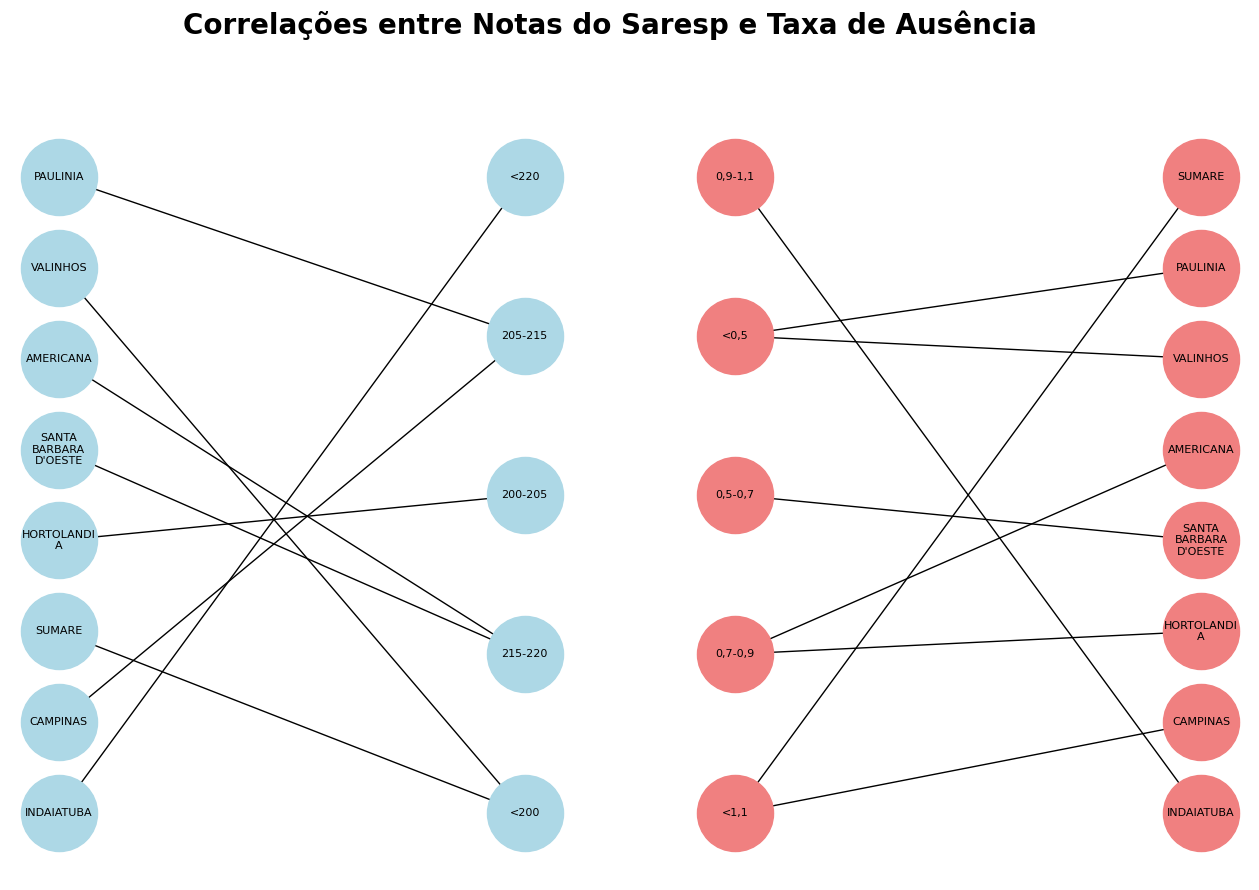

In [22]:
import textwrap

G=nx.Graph()
H=nx.Graph()
H.add_nodes_from(["<0,5","0,5-0,7","0,7-0,9","0,9-1,1","<1,1"])
H.add_nodes_from(docentes_agrupados.index)
G.add_nodes_from(docentes_agrupados.index)
G.add_nodes_from(["<200","200-205","205-215","215-220","<220"])
edge_labels1 = [
    "215-220",
    "205-215",
    "200-205",
    "<220",
    "205-215",
    "215-220",
    "<200",
    "<200"
]
edge_labels2 = [
    "0,7-0,9",
    "<1,1",
    "0,7-0,9",
    "0,9-1,1",
    "<0,5",
    "0,5-0,7",
    "<1,1",
    "<0,5"
]
for i, label in enumerate(edge_labels2):
    H.add_edges_from([(docentes_agrupados.index[i], label)])
for i, label in enumerate(edge_labels1):
    G.add_edges_from([(docentes_agrupados.index[i], label)])

wrapped_labels_G = {n: '\n'.join(textwrap.wrap(n, width=10)) for n in G.nodes()}
wrapped_labels_H = {n: '\n'.join(textwrap.wrap(n, width=10)) for n in H.nodes()}

pos1=nx.bipartite_layout(G, docentes_agrupados.index)
pos2=nx.bipartite_layout(H, edge_labels2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

nx.draw_networkx_nodes(G, pos1, node_color='lightblue', node_size=3000, ax=ax1)
nx.draw_networkx_labels(G, pos1, labels=wrapped_labels_G, font_size=8, ax=ax1)
nx.draw_networkx_edges(G, pos1, ax=ax1, arrows=True)

nx.draw_networkx_nodes(H, pos2, node_color='lightcoral', node_size=3000, ax=ax2)
nx.draw_networkx_labels(H, pos2, labels=wrapped_labels_H, font_size=8, ax=ax2)
nx.draw_networkx_edges(H, pos2, ax=ax2, arrows=True)
fig.suptitle("Correlações entre Notas do Saresp e Taxa de Ausência", fontsize=20, fontweight='bold')
ax1.axis('off')
ax2.axis('off')
plt.show()